# Trends MPI (GCM & MAR-GCM)
# SSP 245 (original)

## 1. Environnement

In [1]:
# import xarray as xr
import pandas as pd
import numpy as np
import calendar as cld
import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.path import Path

from scipy.stats import linregress

#import geopandas as gpd
from pyproj import Proj, transform
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import shapefile
from copy import copy

/Users/peyaudv/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
# Which Computer ?
#path_DIR = '/bettik/beaumetj/'  # On dahu
path_DIR = '/Users/peyaudv/Glaciers/MAR_GCMs/' # Local pc perso
path_IMG = path_DIR+'SavedFigures/'

In [3]:
def get_slopes_and_pvalue(wp_meanseason):

    wp_meanseason_hist = wp_meanseason[:86,:,:,:]
#    wp_meanseason_fut = wp_meanseason[55:,:,:,:]
    
    origin_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    slope_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    pvalue_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    
#    origin_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    slope_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    pvalue_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
    
    for i in range(wp_meanseason.shape[3]):
        # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
        for j in range(wp_meanseason.shape[2]):
            for season in range(4):
                linregress_hist = linregress(np.arange(wp_meanseason_hist.shape[0]), wp_meanseason_hist[:,season,j,i])
                origin_hist[season][j][i] = linregress_hist.intercept
                slope_hist[season][j][i] = linregress_hist.slope
                pvalue_hist[season][j][i] = linregress_hist.pvalue
                
#                linregress_fut = linregress(np.arange(wp_meanseason_fut.shape[0]), wp_meanseason_fut[:,season,j,i])
#                origin_fut[season][j][i] = linregress_fut.intercept
#                slope_fut[season][j][i] = linregress_fut.slope
#                pvalue_fut[season][j][i] = linregress_fut.pvalue

#    return slope_hist, slope_fut, pvalue_hist, pvalue_fut
    return slope_hist, pvalue_hist

## 2. SSP 245

### 2.1 load Data

In [4]:
scenario = 'SSP245' #'HIST' #

In [5]:
wp_meanseason_meanT_245_GCM = np.load(path_DIR+'numpyData/tas_MPI-ESM1-2-HR_SSP245'+'.npz')

In [6]:
print(wp_meanseason_meanT_245_GCM)

NpzFile '/Users/peyaudv/Glaciers/MAR_GCMs/numpyData/tas_MPI-ESM1-2-HR_SSP245.npz' with keys: T_month, T_season, T_year, lon, lat...


In [7]:
yearG=wp_meanseason_meanT_245_GCM['years']
longG=wp_meanseason_meanT_245_GCM['lon']
latiG=wp_meanseason_meanT_245_GCM['lat']
tmonG =wp_meanseason_meanT_245_GCM['T_month']
tsaiG =wp_meanseason_meanT_245_GCM['T_season']
tyeaG =wp_meanseason_meanT_245_GCM['T_year']

In [8]:
print(tsaiG.shape)

(86, 4, 7, 14)


In [9]:
wp_meanseason_meanT_245_MAR = np.load(path_DIR+'numpyData/ttz_MARMPI-ESM_SSP245'+'.npz')

In [10]:
wp_meanseason_meanT_245_MAR['T_season'].shape

(86, 4, 91, 139)

In [11]:
yearM=wp_meanseason_meanT_245_MAR['years']
longM=wp_meanseason_meanT_245_MAR['lon']
latiM=wp_meanseason_meanT_245_MAR['lat']
tmonM =wp_meanseason_meanT_245_MAR['T_month']
tsaiM =wp_meanseason_meanT_245_MAR['T_season']
tyeaM =wp_meanseason_meanT_245_MAR['T_year']
#print(yearM)

In [12]:
WantedMassifPatches=[]
# Download and unzip shapefiles and open the desired one
shapes = shapefile.Reader("s2m_shapefiles/massifs_shapefiles/massifs_alpes_4226.shp")
patches = []
for shape in shapes.shapeRecords():
    massif_number = shape.record[0]
    massif_name = shape.record[1]
    polygon = Polygon(shape.shape.points, ec="none", fc="y", alpha=0.9)#, fill=False,facecolor='None')
    #print(shape.shape.points)
    patches.append(polygon)
    
    #print(shape.record[0],shape.record[1])
    if (massif_name=='Mont-Blanc'): 
        print(massif_name, massif_number)
        polygon_MB = Polygon(shape.shape.points, ec="none", fc="b", alpha=0.9)#, fill=False,facecolor='None')
    if (massif_name=='Vanoise'): 
        print(massif_name, massif_number)
        polygon_VA = Polygon(shape.shape.points, ec="none", fc="r", alpha=0.9)#, fill=False,facecolor='None')
    if (massif_name=='Oisans'): 
        print(massif_name, massif_number)
        polygon_OI = Polygon(shape.shape.points, ec="none", fc="g", alpha=0.9)#, fill=False,facecolor='None')
    if (massif_name=='Mont-Blanc' or massif_name=='Vanoise' or massif_name=='Oisans'):
        WantedMassifPatches.append([massif_name, massif_number])
print(WantedMassifPatches)

Mont-Blanc 3
Vanoise 10
Oisans 15
[['Mont-Blanc', 3], ['Vanoise', 10], ['Oisans', 15]]


### Find Glacioclim XY position

In [13]:
def findXYGlacioclim2 (lonGla,latGla,lonGrid2d,latGrid2d) :
# Find the speed at a certain lat/lon point.
    #Find the index of the grid point nearest a specific lat/lon.   
    abslat = np.abs(latGrid2d-latGla)
    abslon = np.abs(lonGrid2d-lonGla)
    c = np.maximum(abslon, abslat)
    # Return the grid point coordinates (x,y)
    ([xloc], [yloc]) = np.where(c == np.min(c))
    return (xloc, yloc) #([xloc], [yloc])

def findXYGlacioclim1 (lonGla,latGla,lonGrid1d,latGrid1d) :
# Find the speed at a certain lat/lon point.
    #Find the index of the grid point nearest a specific lat/lon.   
    abslat = np.abs(latGrid1d-latGla)
    abslon = np.abs(lonGrid1d-lonGla)
    xloc,yloc = np.where(abslon == np.min(abslon)), np.where(abslat == np.min(abslat))
    return (xloc[0].item(),yloc[0].item())#(xloc, yloc) #([xloc], [yloc])
    # use xloc[0].item() because np.where returns an ndarray

# Glacioclim glaciers location study (lon lat)
glacioClim=[["Argentiere",6.93,45.9], ["Mer de Glace",6.97,45.95], ["Gebroulaz",6.61,45.28], ["Saint Sorlin",6.63,45.15], ["Glacier Blanc",6.37,44.93]]

In [14]:
# X Y coordinates in MAR Grid 
glacioClXYG=[["Argentiere",0,0], ["Mer de Glace",0,0], ["Gebroulaz",0,0], ["Saint Sorlin",0,0], ["Glacier Blanc",0,0]]
glacioClXYM=[["Argentiere",0,0], ["Mer de Glace",0,0], ["Gebroulaz",0,0], ["Saint Sorlin",0,0], ["Glacier Blanc",0,0]]

for i in range(len(glacioClim)):
    #print (i,glacioClim[i][0])
    glacioClXYG[i][1],glacioClXYG[i][2] = findXYGlacioclim1(glacioClim[i][1],glacioClim[i][2],longG,latiG)
    glacioClXYM[i][1],glacioClXYM[i][2] = findXYGlacioclim2(glacioClim[i][1],glacioClim[i][2],longM,latiM)

In [15]:
print(glacioClXYG)

[['Argentiere', 3, 4], ['Mer de Glace', 3, 4], ['Gebroulaz', 3, 3], ['Saint Sorlin', 3, 3], ['Glacier Blanc', 3, 3]]


### 2.2 Plot seasonal temperature (selected years)

In [16]:
# Color scale for the notebook
#cmap, quality = plt.get_cmap('rainbow'), 100 
colo_scale = 'rainbow'
vmin_scale, vmax_scale = -5., 25.
# Define a custom normalization for temperature range (optional)
norm = mcolors.Normalize(vmin=-5, vmax=25)
# Proj
proj = ccrs.PlateCarree()
quality = 100

Polygon43((6.17888, 45.8492) ...)


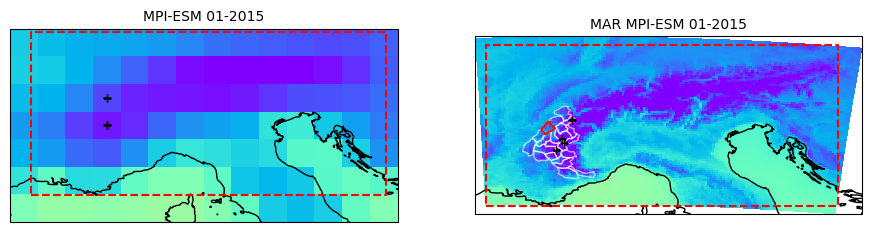

In [17]:
# Plot temperature pour 1er mois
fig, axs = plt.subplots(1, 2, figsize=(11, 3),subplot_kw={'projection': proj},dpi=quality)
#ax = plt.axes(projection=ccrs.PlateCarree())
axs = axs.ravel()

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

axs[0].set_title("MPI-ESM 01-2015",fontsize=10)
axs[1].set_title("MAR MPI-ESM 01-2015",fontsize=10)

# pcolormesh
m = axs[0].pcolormesh(
    longG, latiG, tmonG[0,0],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
m = axs[1].pcolormesh(
    longM, latiM, tmonM[0,0],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)

for i, ax in enumerate(axs):
#ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
   ax.add_feature(cfeature.COASTLINE)
#axs[1].add_feature(cfeature.COASTLINE)

# Tracé du polygone en pointillés rouge
   ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

# Position des glaciers
for i in range(len(glacioClim)):
    # Data GCM 2 vector coordinates LON & LAT
    # Data MAR 2 matrix coordinates (LON,LAT)
    xG, yG = glacioClXYG[i][1], glacioClXYG[i][2]
    xM, yM = glacioClXYM[i][1], glacioClXYM[i][2]
    axs[0].plot(longG[xG],latiG[yG], marker='+',color='black')
    axs[1].plot(longM[xM][yM],latiM[xM][yM], marker='+',color='black')

# 3. Plot shapefiles massifs alpes
if (True):
    collection = PatchCollection(patches)
    collection.set_color('none')
    collection.set_edgecolor('w')
    collection.set_alpha(0.6)
#    collection1 = PatchCollection(patches)
#    axs[0].add_collection(collection)
    axs[1].add_collection(collection)

#Massif Mont Blanc
print(patches[3])
axs[1].plot(patches[3].get_xy()[:, 0],patches[3].get_xy()[:, 1],color='red')

In [18]:
print(glacioClXYM[i][2])

28


In [19]:
if ((yearM[0]!=yearG[0])or(len(yearM)!=len(yearG))):
    print ("WARNING : yearM and yearG are different")
#print(yearM)
#print(yearG)

In [20]:
# Plot 1srt year
an=0
yG, yM=int(yearG[an]), int(yearM[an])

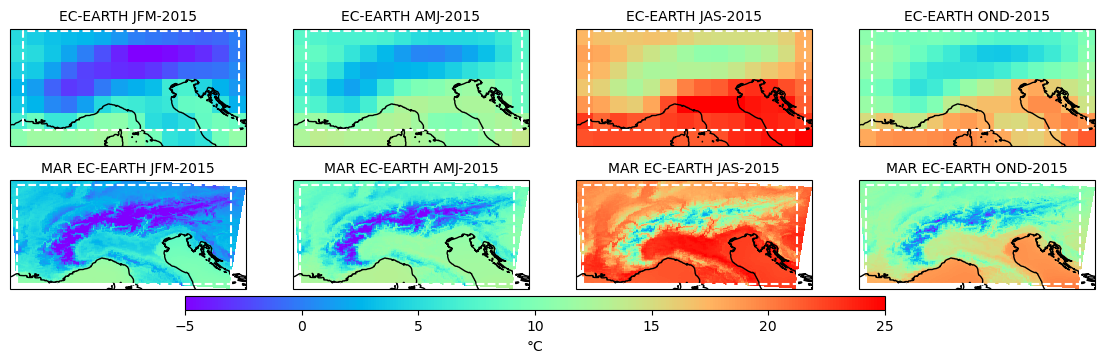

In [21]:
# Plot temperature pour 4 glacier
fig, axs = plt.subplots(2, 4, figsize=(14, 3.5),subplot_kw={'projection': proj},dpi=quality)
#ax = plt.axes(projection=ccrs.PlateCarree())
#axs = axs.ravel()

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

saisons=['JFM','AMJ','JAS','OND']

for i in range(len(saisons)):
    #print(i,saisons[i])
    # ----- GCM -----
    ax = axs[0, i]
    ax.set_title(f"EC-EARTH {saisons[i]}-{yG}",fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longG, latiG, tsaiG[an,i],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())
    # ----- MAR -----
    ax = axs[1, i]
    ax.set_title(f"MAR EC-EARTH {saisons[i]}-{yM}",fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longM, latiM, tsaiM[an,i],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='°C')
plt.savefig(f"{path_IMG}MAR_EC-EARTH_saisons_SSP245_{yM}.png")

In [22]:
# Plot later
an=75 # number of year after the simulation start
yG, yM=int(yearG[an]), int(yearM[an])

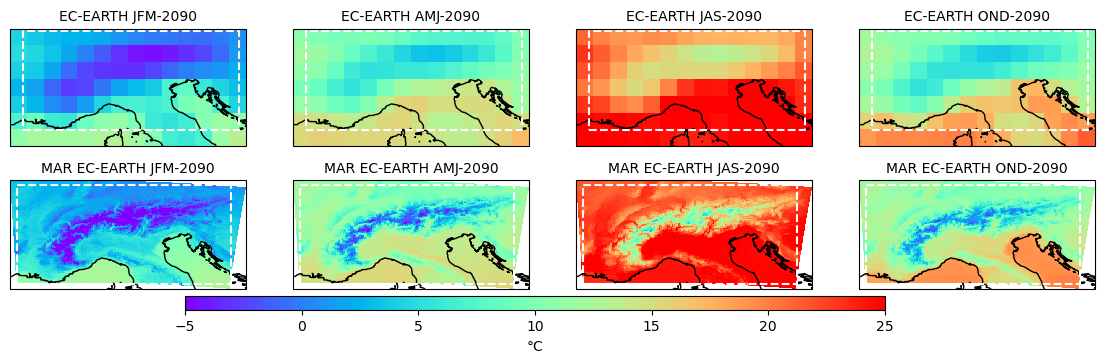

In [23]:
# Plot temperature pour 4 glacier
fig, axs = plt.subplots(2, 4, figsize=(14, 3.5),subplot_kw={'projection': proj},dpi=quality)
#ax = plt.axes(projection=ccrs.PlateCarree())
#axs = axs.ravel()

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

saisons=['JFM','AMJ','JAS','OND']

for i in range(len(saisons)):
    #print(i,saisons[i]) 
    # ----- GCM -----
    ax = axs[0, i]
    ax.set_title(f"EC-EARTH {saisons[i]}-{yG}",fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longG, latiG, tsaiG[55,i],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())
    # ----- MAR -----
    ax = axs[1, i]
    ax.set_title(f"MAR EC-EARTH {saisons[i]}-{yM}",fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longM, latiM, tsaiM[55,i],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='°C')
plt.savefig(f"{path_IMG}MAR_EC-EARTH_saisons_SSP245_{yM}.png")

### 2.3 Plot seasonal temperature trends

In [24]:
# Seasonnal Temperature trend for GCM
slope_TG, pvalue = get_slopes_and_pvalue(tsaiG)

In [25]:
print(slope_TG.shape) # seasons, lon, lat

(4, 7, 14)


In [26]:
# Seasonnal  Temperature trend for MAR
slope_TM, pvalue = get_slopes_and_pvalue(tsaiM)

In [27]:
print(slope_TM.shape) # seasons, lon, lat

(4, 91, 139)


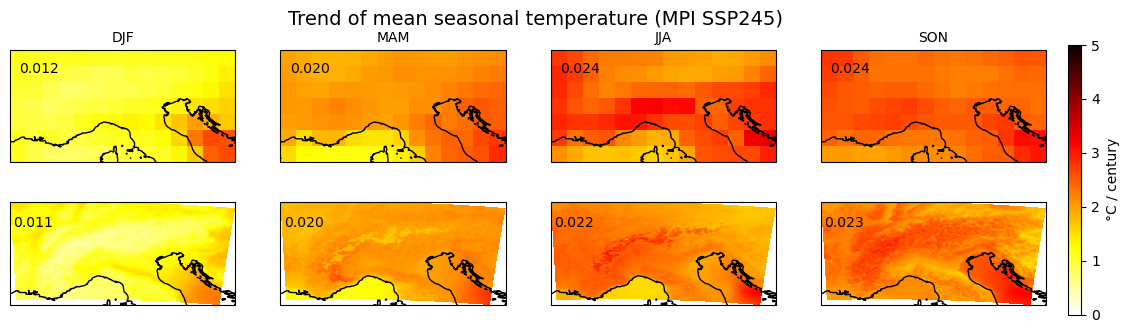

In [28]:
# Plot trends for seasonal temperature for run GCM and MAR
fig, axs = plt.subplots(nrows=2, ncols=4,figsize=(14, 3.5),
    subplot_kw={'projection': proj}, dpi=quality #constrained_layout=True, 
)
# Color scale
colo_scale = 'Oranges'#'coolwarm'
colo_scale = 'hot_r'
vmin_scale, vmax_scale = 0., 5. #-5., 5.
#levels = np.linspace(0, 8, 65)

# Boucle principale
for i in range(4):
#    pcm = ax.pcolormesh(Long, Lati, slope_T_hist[i], cmap='rainbow', vmin=-1., vmax=1.
#) ### Comment otherwise it shifts the panels

    # ----- GCM -----
    ax = axs[0, i]
    #print("hist",slope_T_hist[i,0,0])
    cb = ax.pcolormesh(longG, latiG, 100*slope_TG[i], # 100*slope_T_hist[i] ????????
                       cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
    ax.text(5, 47.5, f"{np.mean(slope_TG[i]):.3f}",
            ha='center', va='center', fontsize=10)
    ax.add_feature(cfeature.COASTLINE)
    
    # ----- MAR -----
    ax = axs[1, i]
    #print("245",slope_T_245[i,0,0])
    ax.pcolormesh(longM, latiM, 100*slope_TM[i],
                  cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
    ax.text(5, 47.5, f"{np.mean(slope_TM[i]):.3f}",
            ha='center', va='center', fontsize=10)
    ax.add_feature(cfeature.COASTLINE)

# ----- Colorbar globale -----
cbar = fig.colorbar(cb, ax=axs, orientation="vertical",
                    fraction=0.025, pad=0.02)
cbar.set_label("°C / century")
#cbar.set_ticks(np.linspace(0, 8, 9))

# ----- Titres colonnes -----
for i, label in enumerate(["DJF", "MAM", "JJA", "SON"]):
    axs[0, i].set_title(label, fontsize=10)
ax.yaxis.set_ticks_position('left')
# ----- Labels lignes -----
for i, label in enumerate(["GCM", "MAR"]):
    # print(label) !!!! WArning ylabel doesn't appear
    axs[i, 0].yaxis.set_ticks_position('right')
    axs[i, 0].set_ylabel(label, fontsize=14, rotation=90)
axs[1, 1].set_ylabel(label, fontsize=14, rotation=90)

fig.suptitle(f"Trend of mean seasonal temperature (MPI {scenario})", fontsize=14)

plt.savefig(f"{path_IMG}MAR_MPI_Trend_Temp_{scenario}_{yearM[0]}-{yearM[-1]}.png")

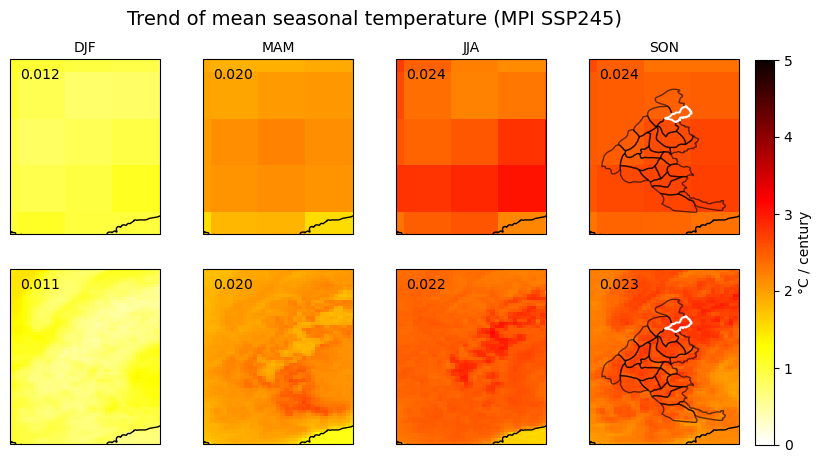

In [29]:
# Plot trends for seasonal temperature for run GCM and MAR
fig, axs = plt.subplots(nrows=2, ncols=4,figsize=(10, 5),
    subplot_kw={'projection': proj}, dpi=quality #constrained_layout=True, 
)
# Color scale
colo_scale = 'Oranges'#'coolwarm'
colo_scale = 'hot_r'
vmin_scale, vmax_scale = 0., 5. #-5., 5.
#levels = np.linspace(0, 8, 65)

# Boucle principale
for i in range(4):
#    pcm = ax.pcolormesh(Long, Lati, slope_T_hist[i], cmap='rainbow', vmin=-1., vmax=1.
#) ### Comment otherwise it shifts the panels

    # ----- GCM -----
    ax = axs[0, i]
    #print("hist",slope_T_hist[i,0,0])
    cb = ax.pcolormesh(longG, latiG, 100*slope_TG[i], # 100*slope_T_hist[i] ????????
                       cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
    ax.text(5.6, 46.7, f"{np.mean(slope_TG[i]):.3f}",
            ha='center', va='center', fontsize=10)
    ax.add_feature(cfeature.COASTLINE)
    
    ax.set_xlim(5,8)
    ax.set_ylim(43.5,47)
    
    # ----- MAR -----
    ax = axs[1, i]
    #print("245",slope_T_245[i,0,0])
    ax.pcolormesh(longM, latiM, 100*slope_TM[i],
                  cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
    ax.text(5.6, 46.7, f"{np.mean(slope_TM[i]):.3f}",
            ha='center', va='center', fontsize=10)
    ax.add_feature(cfeature.COASTLINE)
    
        
    ax.set_xlim(5,8)
    ax.set_ylim(43.5,47)
    
# ----- Colorbar globale -----
cbar = fig.colorbar(cb, ax=axs, orientation="vertical",
                    fraction=0.025, pad=0.02)
cbar.set_label("°C / century")
#cbar.set_ticks(np.linspace(0, 8, 9))

# ----- Titres colonnes -----
for i, label in enumerate(["DJF", "MAM", "JJA", "SON"]):
    axs[0, i].set_title(label, fontsize=10)
ax.yaxis.set_ticks_position('left')
# ----- Labels lignes -----
for i, label in enumerate(["GCM", "MAR"]):
    # print(label) !!!! WArning ylabel doesn't appear
    axs[i, 0].yaxis.set_ticks_position('right')
    axs[i, 0].set_ylabel(label, fontsize=14, rotation=90)
axs[1, 1].set_ylabel(label, fontsize=14, rotation=90)

# 3. Plot shapefiles massifs alpes
if (True):
    collection2 = PatchCollection(patches)
    collection2.set_color('none')
    collection2.set_edgecolor('k')
    collection2.set_alpha(0.6)

    #must copy the paches to recreate a new Artist view
    new_patches=copy(patches)
    collection3 = PatchCollection(new_patches)
    collection3.set_color('none')
    collection3.set_edgecolor('k')
    collection3.set_alpha(0.6)
axs[0,3].add_collection(collection2)
axs[1,3].add_collection(collection3)

# Plot Mont Blanc in red
i_ployg=2 
axs[0,3].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='w')
axs[1,3].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='w')

fig.suptitle(f"Trend of mean seasonal temperature (MPI {scenario})", fontsize=14)

plt.savefig(f"{path_IMG}MAR_MPI_Trend_Temp_{scenario}_{yearM[0]}-{yearM[-1]}_zoom.png")

## 3. Compare on same grid

See https://github.com/Ian-CD/PhD/blob/master/Article_EDW/Figs_1_and_2_and_appendixB.ipynb,
Article from Ian (https://egusphere.copernicus.org/preprints/2025/egusphere-2025-6211/egusphere-2025-6211.pdf)

### 3.1 On MAR Grid

In [30]:
# import utils as u
# import xarray_regrid

# slope_TGonM = np.zeros(np.shape(slope_TM))
# print(np.shape(slope_TM))
# print(np.shape(slope_TG))
# # Plot trends for seasonal temperature for run GCM and MAR
# fig, axs = plt.subplots(nrows=2, ncols=4,figsize=(14, 3.5),
#     subplot_kw={'projection': proj}, dpi=quality #constrained_layout=True, 
# )
# # Color scale
# colo_map = 'hot_r'
# # Boucle principale
# for i in range(4):
#     temp_slope_TG=slope_TG[i]
#     print(temp_slope_TG)
#     slope_TGonM_xy=(temp_slope_TG.reshape(91,139))
# #slope_TGonM
# #slope_TG[i]
# #slope_TM[i]

### 3.2 On GCM Grid

In [31]:
colmap = 'hot_r'
slope_TMonG = np.zeros(np.shape(slope_TG))

### 3.3 At Glacioclim location 

In [32]:
# number of years
print(yearG[-1],yearG[0])
yearG[-1]-yearG[0]+1
nby=int(yearG[-1].item()-yearG[0].item()+1)

2100.0 2015.0


In [33]:
#Define period for mean calculation
first_year_mean, last_year_mean = 2015, 2099 # 1960, 1990
temp = np.where( yearM == np.min(first_year_mean) ) # index of meantime first year in array of years
iy_i = temp[0].item()
temp = np.where( yearM == np.min(last_year_mean)  ) # index of meantime last...
iy_f = temp[0].item()
print(f"Index first, last years: {iy_i}, {iy_f}")

Index first, last years: 0, 84


In [34]:
# Calculate average on a given period

# Annual Temperature
glacioClT_yearG = np.zeros((nby,5)) # GCM
glacioClT_yearM = np.zeros((nby,5)) # MAR
# Seasonnal Temperature
glacioClT_seasG = np.zeros((nby,5,4))
glacioClT_seasM = np.zeros((nby,5,4))

# Mean Annual Temperature
glacioClTmean_yearG = np.zeros(5)
glacioClTmean_yearM = np.zeros(5)
# Mean Seasonnal Temperature
glacioClTmean_seasG = np.zeros((5,4))
glacioClTmean_seasM = np.zeros((5,4))
#glacioClTmean_seasG

In [35]:
tmonG.shape

(86, 12, 7, 14)

In [36]:
tmonG[iy_i:iy_f,:,0,0].shape

(84, 12)

In [37]:
# Position des glaciers
for i in range(len(glacioClim)):
    # Data GCM 2 vector coordinates LON & LAT
    # Data MAR 2 matrix coordinates (LON,LAT)
    xG, yG = glacioClXYG[i][1], glacioClXYG[i][2]
    xM, yM = glacioClXYM[i][1], glacioClXYM[i][2]

    # Annual Temp
    for y in range(len(yearG)):
        glacioClT_yearG[y,i] = np.average(tmonG[y,:,xG,yG])
        glacioClT_yearM[y,i] = np.average(tmonM[y,:,xM,yM])

    # Mean Annual Temp
    glacioClTmean_yearG[i] = np.average(tmonG[iy_i:iy_f,:,xG,yG])
    glacioClTmean_yearM[i] = np.average(tmonM[iy_i:iy_f,:,xM,yM])

    # Seasonnal Temp
    for y in range(len(yearG)):    
        #print(tsaiG[y,:,xG,yG])
        glacioClT_seasG[y,i,:] = tsaiG[y,:,xG,yG]
        glacioClT_seasM[y,i,:] = tsaiM[y,:,xM,yM]
    
    # Mean Seasonnal Temp
    for s in range(4):
        glacioClTmean_seasG[i][s] = np.average(tsaiG[iy_i:iy_f,s,xG,yG]) 
        glacioClTmean_seasM[i][s] = np.average(tsaiM[iy_i:iy_f,s,xM,yM])

In [38]:
#print(glacioClT_seasG)

In [39]:
print("Check the size of data Array:")
print(tmonG.shape)
print(tsaiG.shape)
print(glacioClTmean_yearM.shape)
print(glacioClTmean_seasM.shape)
print(glacioClT_seasM.shape)

Check the size of data Array:
(86, 12, 7, 14)
(86, 4, 7, 14)
(5,)
(5, 4)
(86, 5, 4)


In [40]:
# Plot 1 : massif du Mont Blanc 4 saisons
print("glacioClT_yearG : GCM Annual and Mean Temp at all glacioclim location:")
print(glacioClT_yearG.shape)
print(glacioClTmean_yearG.shape)

glacioClT_yearG : GCM Annual and Mean Temp at all glacioclim location:
(86, 5)
(5,)


0 DJF
1 MAM
2 JJA
3 SON


Text(0.5, 0.98, 'Temperature for all Glacioclim Glaciers')

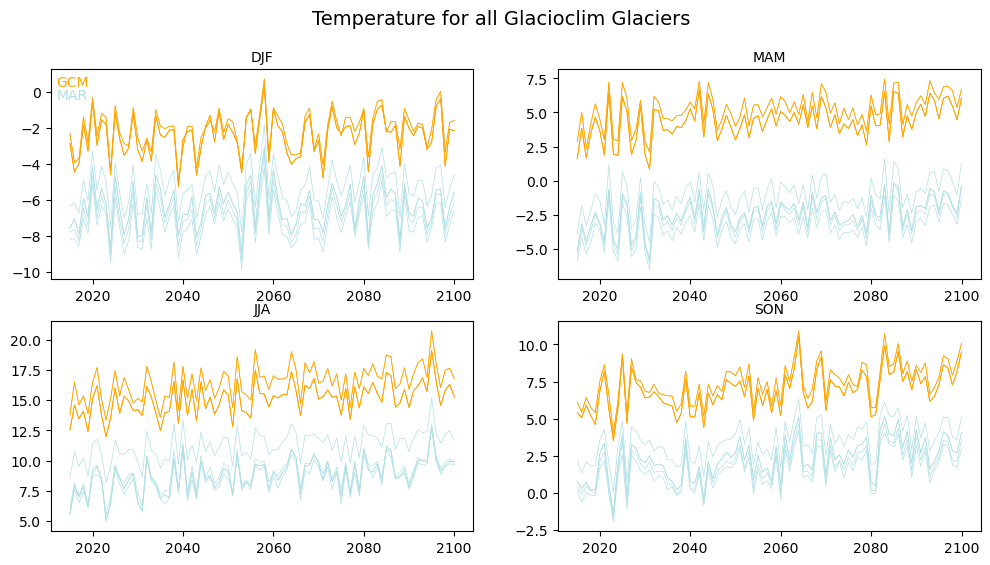

In [41]:
#Plot temperatures mensuelles pour 4 glacier
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs.ravel()
#for i, 
labelseasons = ["DJF", "MAM", "JJA", "SON"]

s = 0 # seasons

for i in range(len(axs)):
    for j in range(len(axs[0])):
        label = labelseasons[s]
        print(s, label)
        ax = axs[i][j]
        ax.set_title(labelseasons[s], fontsize=10)
        for ii in range(len(glacioClXYG)):
            ax.plot(yearG,glacioClT_seasG[:,ii,s],'orange',lw=0.5) 
            ax.plot(yearG,glacioClT_seasM[:,ii,s],'powderblue',lw=0.5)
            #ax.plot(yearG,glacioClT_seasG[:,ii,s]-glacioClTmean_seasG[ii,s],'k',lw=0.5) 
            #ax.plot(yearG,glacioClT_seasM[:,ii,s]-glacioClTmean_seasM[ii,s],'b',lw=0.5)
        s=s+1

axs[0,0].text(2012,0.3,'GCM',color='orange')
axs[0,0].text(2012,-0.4,'MAR',color='powderblue')
fig.suptitle(f"Temperature for all Glacioclim Glaciers", fontsize=14)

Text(0.5, 0.98, 'Temperature for Glacioclim Glaciers (JJA)')

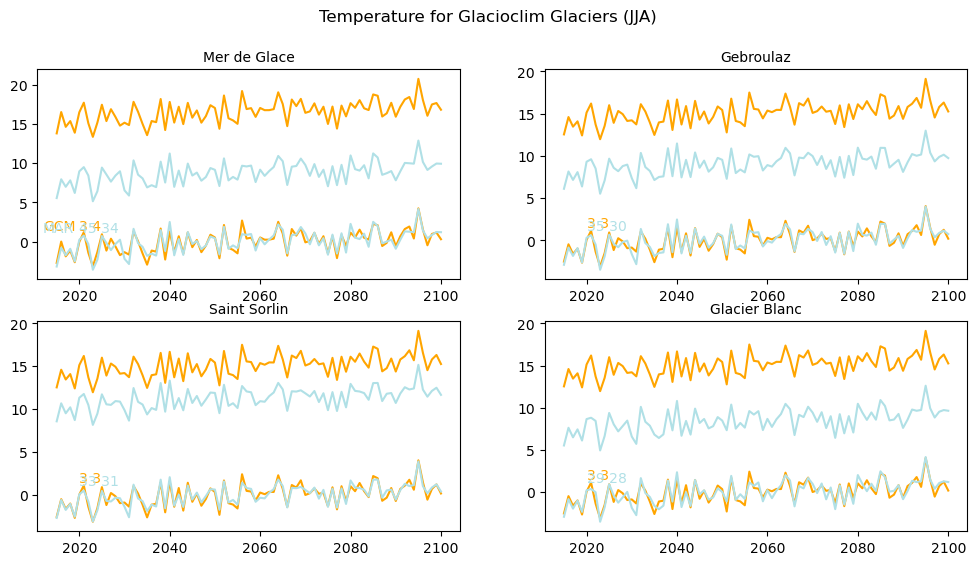

In [42]:
# Computing trends for all Glacioclim glacier (Temperature linear regression)
slope_T_loc=np.full(5,np.nan)
pvalue_T_loc=np.full(5,np.nan)
intercept_T_loc=np.full(5,np.nan)

#Plot temperatures mensuelles pour 4 glacier
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs = axs.ravel()

s = 2 # summer

for i, ax in enumerate(axs):
    ii=i+1
    glaName,xloc,yloc = glacioClXYG[ii][:] # ii=i+1 because 5 glaciers and 2 first are in same pixel (Arg and MdG)
    xG, yG = glacioClXYG[ii][1], glacioClXYG[ii][2]
    xM, yM = glacioClXYM[ii][1], glacioClXYM[ii][2]

    ax.plot(yearG,glacioClT_seasG[:,ii,s],color='orange')      # T Seas
    ax.plot(yearG,glacioClT_seasM[:,ii,s],color='powderblue')     
    ax.plot(yearG,glacioClT_seasG[:,ii,s]-glacioClTmean_seasG[ii,s],color='orange')      # T Seas
    ax.plot(yearG,glacioClT_seasM[:,ii,s]-glacioClTmean_seasM[ii,s],color='powderblue')        # T Seas
    ax.text(2020,1.5,f'{xG} {yG}',color='orange')
    ax.text(2020,1.2,f'{xM} {yM}',color='powderblue')    
    #ax.plot(yearG,glacioClT_yearM[:,ii])        # T Ann

    #print(glacioClTmean_yearG[ii])
    #print(np.mean(tannG[:,1,xG,yG]))
    # Computing trends

    
    ax.set_title(glaName,fontsize=10)

axs[0].text(2012,1.5,'GCM',color='orange')
axs[0].text(2012,1.2,'MAR',color='powderblue')

fig.suptitle(f"Temperature for Glacioclim Glaciers ({labelseasons[s]})", fontsize=12)

In [43]:
# Color scale for the notebook
#cmap, quality = plt.get_cmap('rainbow'), 100 
colo_scale = 'rainbow'
vmin_scale, vmax_scale = -5., 25.
# Define a custom normalization for temperature range (optional)
norm = mcolors.Normalize(vmin=-5, vmax=25)
# Proj
proj = ccrs.PlateCarree()
quality = 100

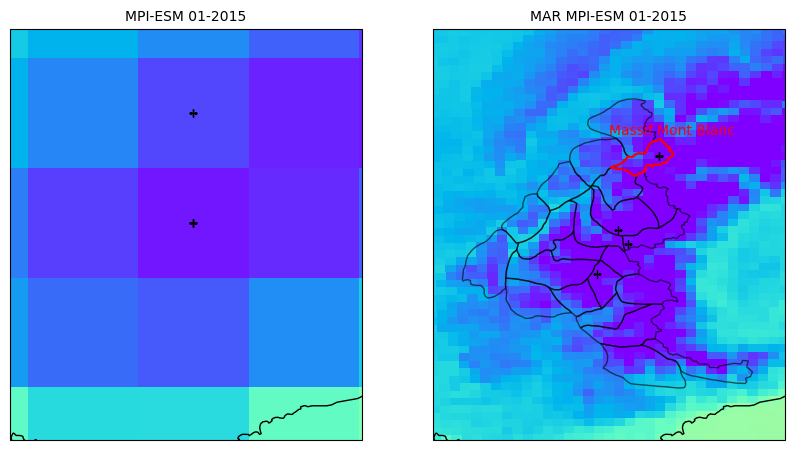

In [44]:
# Plot temperature pour 1er mois
fig, axs = plt.subplots(1, 2, figsize=(10, 6),subplot_kw={'projection': proj},dpi=quality)
#ax = plt.axes(projection=ccrs.PlateCarree())
axs = axs.ravel()

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

axs[0].set_title("MPI-ESM 01-2015",fontsize=10)
axs[1].set_title("MAR MPI-ESM 01-2015",fontsize=10)

# pcolormesh
m = axs[0].pcolormesh(
    longG, latiG, tmonG[0,0],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
m = axs[1].pcolormesh(
    longM, latiM, tmonM[0,0],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)

for i, ax in enumerate(axs):
#ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
   ax.add_feature(cfeature.COASTLINE)
#axs[1].add_feature(cfeature.COASTLINE)

# Tracé du polygone en pointillés rouge
   ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

   ax.set_xlim(5,8)
   ax.set_ylim(43.5,47)
    
# Position des glaciers (black '+')
for i in range(len(glacioClim)):
    # Data GCM 2 vector coordinates LON & LAT
    # Data MAR 2 matrix coordinates (LON,LAT)
    xG, yG = glacioClXYG[i][1], glacioClXYG[i][2]
    xM, yM = glacioClXYM[i][1], glacioClXYM[i][2]
    axs[0].plot(longG[xG],latiG[yG], marker='+',color='black')
    axs[1].plot(longM[xM][yM],latiM[xM][yM], marker='+',color='black')

# 3. Plot shapefiles massifs alpes
if (True):
    collection = PatchCollection(patches)
    collection.set_color('none')
    collection.set_edgecolor('k')
    collection.set_alpha(0.6)
#    collection1 = PatchCollection(patches)
#    axs[0].add_collection(collection)
    axs[1].add_collection(collection)
#    axs[0].autoscale_view()
print(collection)


# Plot Mont Blanc in red
i_ployg=2 
axs[1].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='red')


axs[1].text(6.5,46.1,"Massif Mont Blanc",color="r")
fig.savefig("Temperature_Jan_2015.png")

### 3.4 For a massif

In [45]:
### ### Create a mask for the massif
### 1. Create the polygon
### 2. Create the 2D mask that will contain(lon,lat) at each point mask[i,j] 
### 3. Create a 2D table that will contain the (i,j) at each point table[i,j]
### 4. Fill the mask and the table
### 5. Does the points (lon,lat) are inside the poygon
###   a   Reshape Massif 2D -> 1D 
###   b   Belonging test : True if Inside poygon, False elsewhere 
###   c   Reshape 1D -> 2D
### 6. Update 2D mask and 2D table : values only for massif

# 1. Création du polygone
path = Path(patches[i_ployg].get_xy())
print(longM.shape)
# 2. 3.
Massif2D = np.zeros((91,139,2))
ij_table = np.zeros((91,139,2))
# 4.
for i in range(len(longM[:,0])):
    for j in range(len(longM[0,:])):
        #print(Massif_MB[i,j],[longM[i,j].item(),latiM[i,j].item()])
        Massif2D[i,j,:]=[longM[i,j].item(),latiM[i,j].item()]
        ij_table[i,j,:]=[i,j]

# 5. Test d'appartenance
# 5.a
print("Massif2D.shape",Massif2D.shape)
Massif1D = Massif2D.reshape(91*139,2)
print("Reshaped: Massif1D.shape",Massif1D.shape)
# 5.b
mask1D = path.contains_points(Massif1D)
# 5.c 
mask2D = mask1D.reshape(91,139)
print('1D mask.shape',mask1D.shape)
print('2D mask.shape',mask2D.shape)
print(mask2D)

# 6. 
inside_points0 = Massif1D[mask1D] # Useless
inside_points_lola = Massif2D[mask2D]
inside_points_ij = ij_table[mask2D]

print('ip1',inside_points_ij)
for lola in inside_points_lola :
  axs[1].plot(lola[0],lola[1],'+')
    
print(inside_points_ij.shape)

(91, 139)
Massif2D.shape (91, 139, 2)
Reshaped: Massif1D.shape (12649, 2)
1D mask.shape (12649,)
2D mask.shape (91, 139)
[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]
ip1 [[43. 31.]
 [43. 32.]
 [44. 31.]
 [44. 32.]
 [44. 33.]
 [44. 34.]
 [45. 32.]
 [45. 33.]
 [45. 34.]
 [45. 35.]
 [46. 33.]
 [46. 34.]
 [46. 35.]
 [47. 34.]]
(14, 2)


In [46]:
# Annual Temperature
MBT_yearG = np.zeros((nby,len(inside_points_ij)))
MBT_yearM = np.zeros((nby,len(inside_points_ij)))
# Seasonnal Temperature
MBT_seasG = np.zeros((nby,len(inside_points_ij),4))
MBT_seasM = np.zeros((nby,len(inside_points_ij),4))

# Mean Annual Temperature
MBTmean_yearG = np.zeros(len(inside_points_ij))
MBTmean_yearM = np.zeros(len(inside_points_ij))
# Mean Seasonnal Temperature
MBTmean_seasG = np.zeros((len(inside_points_ij),4))
MBTmean_seasM = np.zeros((len(inside_points_ij),4))
#glacioClTmean_seasG


# Moyenne pour tous les points MAR du massif

for i in range(len(inside_points_ij)):
    # Data MAR 2 matrix coordinates (LON,LAT)
    #print(inside_points1)
    xM, yM = int(inside_points_ij[i][0]), int(inside_points_ij[i][1])
    # print(xM, yM)
    
    # Mean Annual Temp
    MBTmean_yearM[i] = np.average(tmonM[iy_i:iy_f,:,xM,yM])
    # Annual Temp
    for y in range(len(yearG)):
        MBT_yearM[y,i] = np.average(tmonM[y,:,xM,yM])
    # Season,nal Temp
    for s in range(4): 
        MBTmean_seasM[i][s] = np.average(tsaiM[iy_i:iy_f,s,xM,yM])
    #print(i,xM, yM, glacioClTmean_seasG[i], glacioClTmean_seasM[i])

glacier:  Mer de Glace


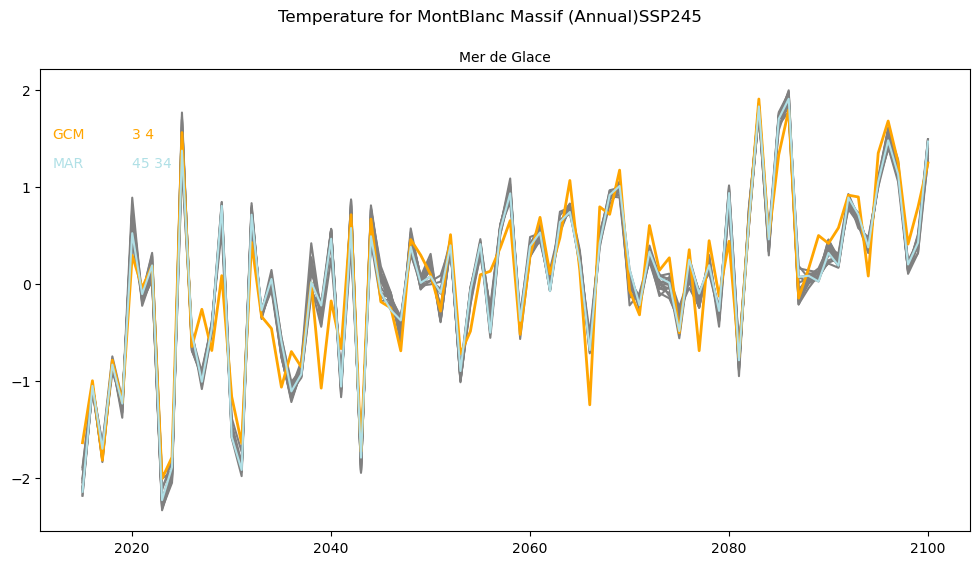

In [47]:
# Same figure with all point in a massif
#For 1 glacier : Mont Blanc
ii=1 # Mer de Glace
print ("glacier: ",glacioClXYG[ii][0])

#Plot temperatures mensuelles pour 4 glacier
fig, ax = plt.subplots(1, figsize=(12, 6))
#axs = axs.ravel()

glaName,xloc,yloc = glacioClXYG[ii][:] # ii=i+1 because 5 glaciers and 2 first are in same pixel (Arg and MdG)
xG, yG = glacioClXYG[ii][1], glacioClXYG[ii][2]
xM, yM = glacioClXYM[ii][1], glacioClXYM[ii][2]

# Loop on all the point of the massif
for pt in range(len(inside_points_ij)): 
        ax.plot(yearG,MBT_yearM[:,pt]-MBTmean_yearM[pt],color='grey') # -MBTmean_yearM[pt]
   
ax.plot(yearG,glacioClT_yearG[:,ii]-glacioClTmean_yearG[ii],color='orange',lw=2)      # T Ann -glacioClTmean_yearG[ii]
ax.plot(yearG,glacioClT_yearM[:,ii]-glacioClTmean_yearM[ii],color='powderblue')        # T Ann -glacioClTmean_yearM[ii]


ax.text(2020,1.5,f'{xG} {yG}',color='orange')
ax.text(2020,1.2,f'{xM} {yM}',color='powderblue')    
    #ax.plot(yearG,glacioClT_yearM[:,ii])        # T Ann

    #print(glacioClTmean_yearG[ii])
    #print(np.mean(tannG[:,1,xG,yG]))
    # Computing trends

    
ax.set_title(glaName,fontsize=10)

ax.text(2012,1.5,'GCM',color='orange')
ax.text(2012,1.2,'MAR',color='powderblue')

fig.suptitle(f"Temperature for MontBlanc Massif (Annual){scenario}", fontsize=12)
fig.savefig(f"TemperatureforMontBlancMassif(Annual)_{scenario}.png")

In [48]:
# Open Topo MAR (surface elevation)
wp_Topo_MAR = np.load(path_DIR+'numpyData/topo_MAR_SurfaceH'+'.npz')
print(wp_Topo_MAR)
topoMAR=wp_Topo_MAR['SH']

NpzFile '/Users/peyaudv/Glaciers/MAR_GCMs/numpyData/topo_MAR_SurfaceH.npz' with keys: SH


In [49]:
labelseasons = ["DJF", "MAM", "JJA", "SON"]
# Altitude
topoMassif = np.zeros(len(inside_points_ij))
# Temperature trend MAR
MBT_trend_seasM = np.zeros((len(labelseasons),len(inside_points_ij)))
#print(MBT_trend_seasM)

# Mean Annual Temperature
MBTmean_yearG = np.zeros(len(inside_points_ij))
MBTmean_yearM = np.zeros(len(inside_points_ij))

print(MBT_trend_seasM.shape)
print(slope_TM.shape)

for i in range(len(inside_points_ij)):
    # Data MAR 2 matrix coordinates (LON,LAT)
    #print(inside_points1)
    xM, yM = int(inside_points_ij[i][0]), int(inside_points_ij[i][1])
    # Fill Altitude
    topoMassif[i] = topoMAR[xM,yM]
    for s in range(len(labelseasons)):
        MBT_trend_seasM[s,i] = slope_TM[s,xM,yM]

#print(MBT_trend_seasM)
#print(topoMassif)

(4, 14)
(4, 91, 139)


In [50]:
slope_TG.shape

(4, 7, 14)

In [51]:
MBT_trend_seasG = np.zeros((len(labelseasons),len(inside_points_ij)))
i=1
xG, yG = glacioClXYG[i][1], glacioClXYG[i][2]
# Temperature trend GCM

for s in range(4):
    MBT_trend_seasG[s] = slope_TG[s,xG,yG]
print(MBT_trend_seasG)

[[0.0093497  0.0093497  0.0093497  0.0093497  0.0093497  0.0093497
  0.0093497  0.0093497  0.0093497  0.0093497  0.0093497  0.0093497
  0.0093497  0.0093497 ]
 [0.02128759 0.02128759 0.02128759 0.02128759 0.02128759 0.02128759
  0.02128759 0.02128759 0.02128759 0.02128759 0.02128759 0.02128759
  0.02128759 0.02128759]
 [0.02811069 0.02811069 0.02811069 0.02811069 0.02811069 0.02811069
  0.02811069 0.02811069 0.02811069 0.02811069 0.02811069 0.02811069
  0.02811069 0.02811069]
 [0.02664864 0.02664864 0.02664864 0.02664864 0.02664864 0.02664864
  0.02664864 0.02664864 0.02664864 0.02664864 0.02664864 0.02664864
  0.02664864 0.02664864]]


0 DJF
Argentiere 45 34 2449.735
Mer de Glace 45 34 2449.735
1 MAM
Argentiere 45 34 2449.735
Mer de Glace 45 34 2449.735
2 JJA
Argentiere 45 34 2449.735
Mer de Glace 45 34 2449.735
3 SON
Argentiere 45 34 2449.735
Mer de Glace 45 34 2449.735


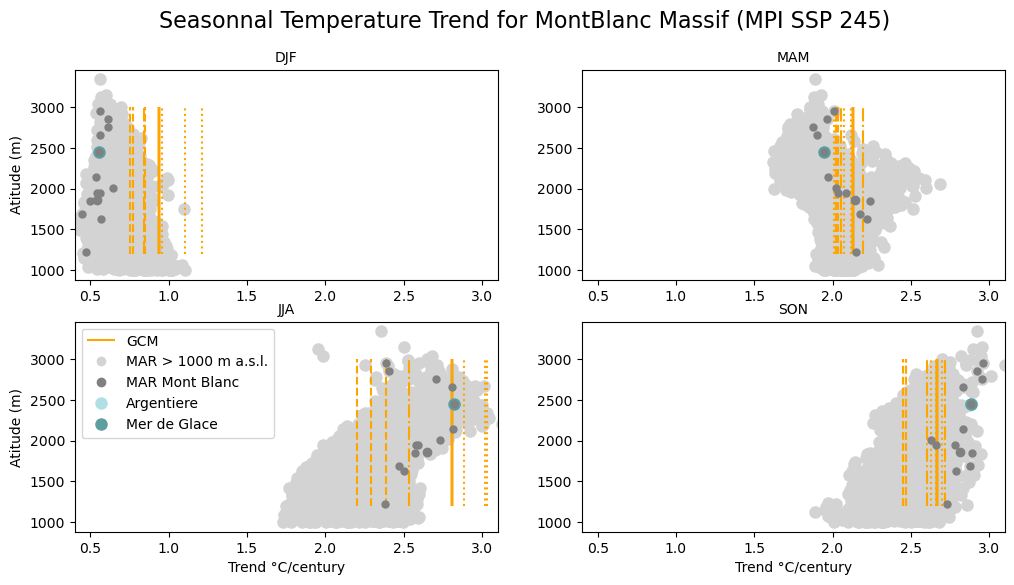

In [53]:
# Figure trend for all point in a massif
#For 1 glacier : Mont Blanc

fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs.ravel()
#for i, 
labelseasons = ["DJF", "MAM", "JJA", "SON"]

s = 0 # seasons

for i in range(len(axs)):
    for j in range(len(axs[0])):
        label = labelseasons[s]
        print(s, label)
        ax = axs[i][j]
        ax.set_title(labelseasons[s], fontsize=10)
        
        # MAR
        # French Alps
        for ii in range(20,80):
            for jj in range(10,110):
                if topoMAR[ii, jj] >=1000:
                    ax.plot(100*slope_TM[s,ii,jj],topoMAR[ii,jj],'o',ms=8,color='lightgrey')
        
        # GCM
        ax.vlines(x=100*MBT_trend_seasG[s], ymin=1200, ymax=3000,color='orange', label='GCM')
        #neighbor points
        ax.vlines(x=100*slope_TG[s,xG-1,yG-1], ymin=1200, ymax=3000,color='orange',ls=':')
        ax.vlines(x=100*slope_TG[s,xG-1,yG], ymin=1200, ymax=3000,color='orange',ls=':')
        ax.vlines(x=100*slope_TG[s,xG-1,yG+1], ymin=1200, ymax=3000,color='orange',ls=':')

        ax.vlines(x=100*slope_TG[s,xG,yG-1], ymin=1200, ymax=3000,color='orange',ls='-.')
        ax.vlines(x=100*slope_TG[s,xG,yG+1], ymin=1200, ymax=3000,color='orange',ls='-.')

        ax.vlines(x=100*slope_TG[s,xG+1,yG-1], ymin=1200, ymax=3000,color='orange',ls='--')
        ax.vlines(x=100*slope_TG[s,xG+1,yG], ymin=1200, ymax=3000,color='orange',ls='--')
        ax.vlines(x=100*slope_TG[s,xG+1,yG+1], ymin=1200, ymax=3000,color='orange',ls='--')
        
        # MAR
        #Mont Blanc
        ax.plot(100*MBT_trend_seasM[s,0],topoMassif[0],'o',color='lightgrey',label='MAR > 1000 m a.s.l.')
        ax.plot(100*MBT_trend_seasM[s,0],topoMassif[0],'o',color='grey',label='MAR Mont Blanc')
        
        # Arg & MdG
        ii=0
        nameM, xM, yM = glacioClXYM[ii][0], glacioClXYM[ii][1],glacioClXYM[ii][2]
        print(nameM, xM, yM,topoMAR[xM, yM])
        ax.plot(100*slope_TM[s,xM,yM],topoMAR[xM, yM],'o',ms=8,color='powderblue',label=nameM)
        ii=1
        nameM, xM, yM = glacioClXYM[ii][0], glacioClXYM[ii][1],glacioClXYM[ii][2]
        print(nameM, xM, yM,topoMAR[xM, yM])
        ax.plot(100*slope_TM[s,xM,yM],topoMAR[xM, yM],'o',ms=8,color='cadetblue',label=nameM)
        
        # Loop on all the point of the massif
        for pt in range(len(inside_points_ij)): 
            ax.plot(100*MBT_trend_seasM[s,pt],topoMassif[pt],'o',color='grey',ms=5)
        
        ax.set_xlim(.4,3.1)
        s=s+1

axs[1,0].set_xlabel('Trend °C/century')
axs[1,1].set_xlabel('Trend °C/century')
axs[0,0].set_ylabel('Atitude (m)')
axs[1,0].set_ylabel('Atitude (m)')
axs[1,0].legend(loc='upper left')


fig.suptitle(f"Seasonnal Temperature Trend for MontBlanc Massif (MPI SSP 245)", fontsize=16)
fig.savefig(f"{path_IMG}SeasonnalTemperatureTrendforMontBlancMassif_MPI_SSP245.png")